In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
earthquake_data = pd.read_csv('./earthquake_data_tsunami.csv') 


# Phase 1: Data Understanding - Complete Analysis

In [ ]:
# 1. Check data dimensions and types 
print("\nDATA DIMENSIONS")
print(f"Shape: {earthquake_data.shape}")
print(f"Columns: {len(earthquake_data.columns)}")
print(f"Rows: {len(earthquake_data)}\n")
print(earthquake_data.info())
print("\nData Arithmetic:\n", earthquake_data.describe().T)


DATA DIMENSIONS
Shape: (782, 13)
Columns: 13
Rows: 782

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB
None

Data Arithmetic:
            count         mean         std        min         25%        50%  \
magnitude  782.0     6.941125    0.445514     6.5000     6.60000     6.8000   
cdi        782.0

In [4]:
# 2. Check for missing values
print("MISSING VALUES ANALYSIS")
missing_values = earthquake_data.isnull().sum()
print(f"\nTotal missing values: {missing_values.sum()}")

MISSING VALUES ANALYSIS

Total missing values: 0


In [5]:
# 3. Analyze target variable (magnitude) distribution
print("\nMAGNITUDE (TARGET) ANALYSIS")
print(earthquake_data['magnitude'].describe())


MAGNITUDE (TARGET) ANALYSIS
count    782.000000
mean       6.941125
std        0.445514
min        6.500000
25%        6.600000
50%        6.800000
75%        7.100000
max        9.100000
Name: magnitude, dtype: float64


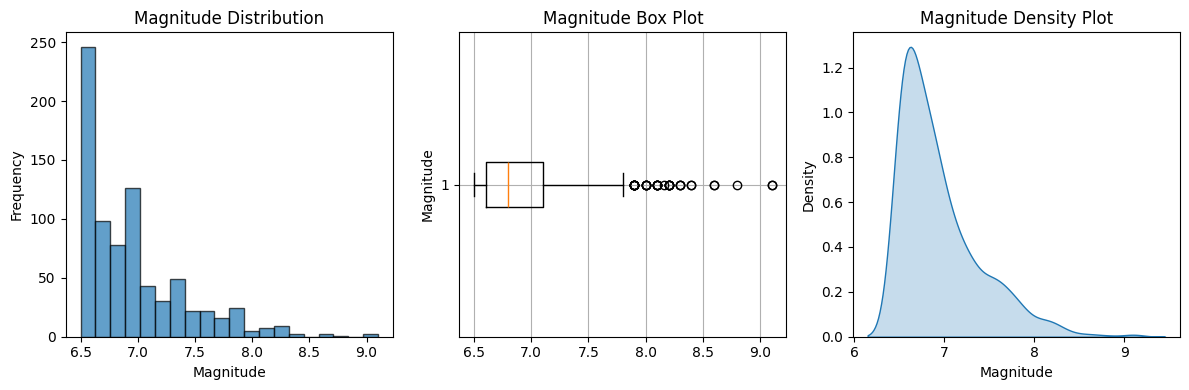

In [6]:
# Visualize magnitude distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(earthquake_data['magnitude'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Magnitude Distribution')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(earthquake_data['magnitude'], orientation='horizontal')
plt.grid(True)
plt.title('Magnitude Box Plot')
plt.ylabel('Magnitude')

plt.subplot(1, 3, 3)
sns.kdeplot(earthquake_data['magnitude'], fill=True)
plt.title('Magnitude Density Plot')
plt.xlabel('Magnitude')

plt.tight_layout()
plt.show()

In [ ]:
# 4. Correlation analysis
print("\nCORRELATION ANALYSIS ===")

numeric_cols = earthquake_data.select_dtypes(include=[np.number]).columns
correlation_matrix = earthquake_data[numeric_cols].corr()


magnitude_corr = correlation_matrix['magnitude'].sort_values(ascending=False)
print("Correlation with Magnitude:")
print(magnitude_corr)


CORRELATION ANALYSIS ===
Correlation with Magnitude:
magnitude    1.000000
sig          0.515871
mmi          0.285552
cdi          0.209549
nst          0.113114
depth        0.030644
tsunami     -0.004726
latitude    -0.008552
Month       -0.011926
longitude   -0.013911
Year        -0.057083
dmin        -0.091403
gap         -0.110626
Name: magnitude, dtype: float64


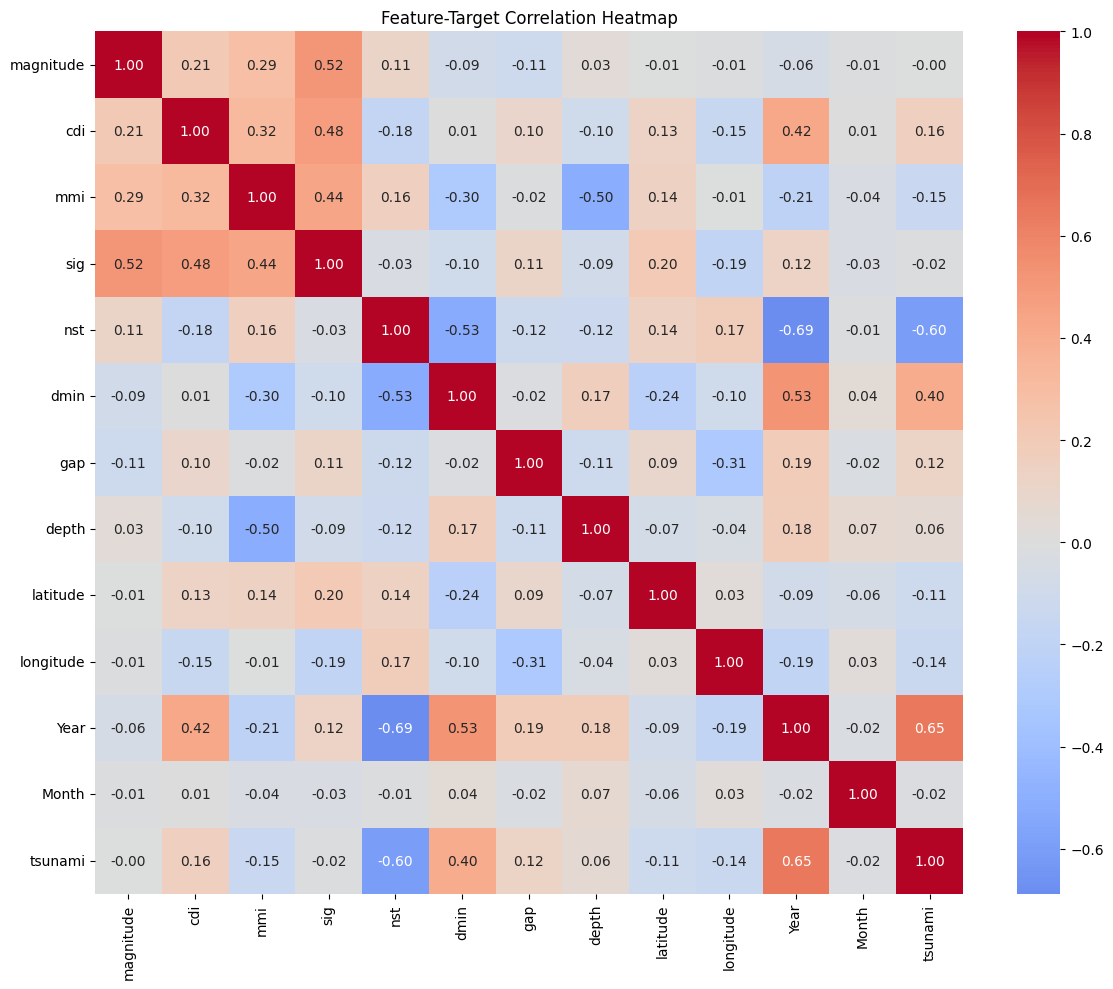

In [8]:
# Heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature-Target Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# 5. Outlier detection using IQR method
key_features = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
for feature in key_features:
    fig = px.histogram(earthquake_data, x=feature, nbins=40, marginal='box', title=f'{feature.capitalize()} Distribution')
    fig.update_layout(bargap=0.1)
    fig.show()

In [ ]:
# 5. Outlier detection using IQR method
print("\nOUTLIER DETECTION")
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers for key features
key_features = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
for feature in key_features:
    outliers, lower, upper = detect_outliers_iqr(earthquake_data, feature)
    print(f"{feature}: {len(outliers)} outliers detected")
    if len(outliers) > 0:
        print(f"  Range: [{lower:.2f}, {upper:.2f}]")
        print(f"  Outlier values: {list(map(float, sorted(outliers[feature].values)[:5]))}...")  # Show first 5
    print()


OUTLIER DETECTION
magnitude: 37 outliers detected
  Range: [5.85, 7.85]
  Outlier values: [7.9, 7.9, 7.9, 7.9, 7.9]...

depth: 139 outliers detected
  Range: [-39.62, 103.38]
  Outlier values: [105.0, 106.0, 107.0, 107.0, 108.0]...

cdi: 0 outliers detected

mmi: 1 outliers detected
  Range: [2.00, 10.00]
  Outlier values: [1.0]...

sig: 73 outliers detected
  Range: [362.88, 1237.88]
  Outlier values: [1245.0, 1247.0, 1248.0, 1252.0, 1267.0]...




FEATURE DISTRIBUTIONS


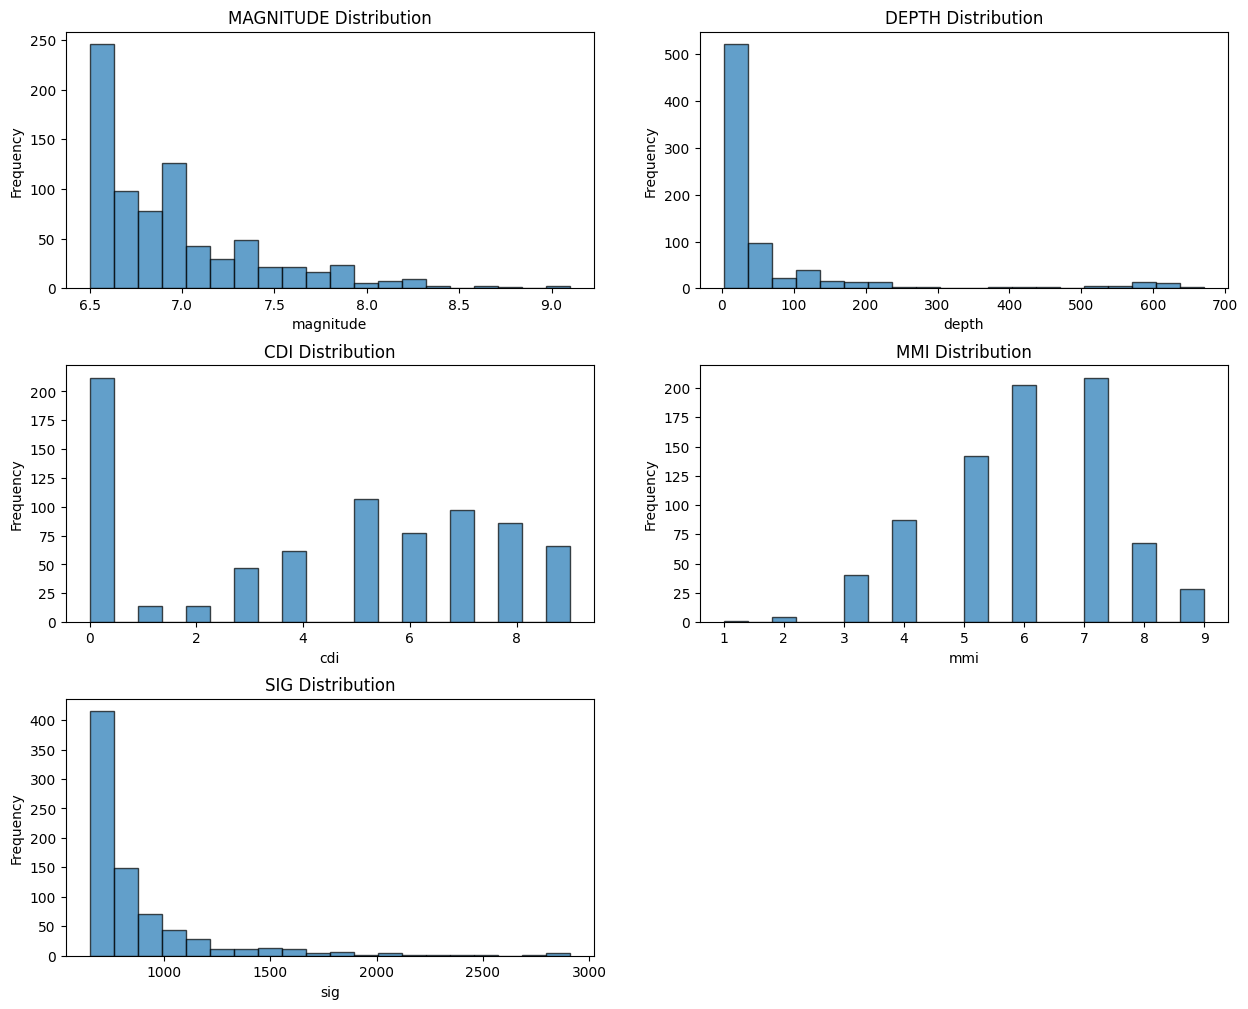

In [ ]:
# 6. Distribution analysis for key features
print("\nFEATURE DISTRIBUTIONS")
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.subplots_adjust(hspace=0.3)
fig.delaxes(axes[2, 1])  
axes = axes.ravel()

for i, feature in enumerate(key_features[:5]):  # Plot first 5 features
    axes[i].hist(earthquake_data[feature], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature.upper()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')




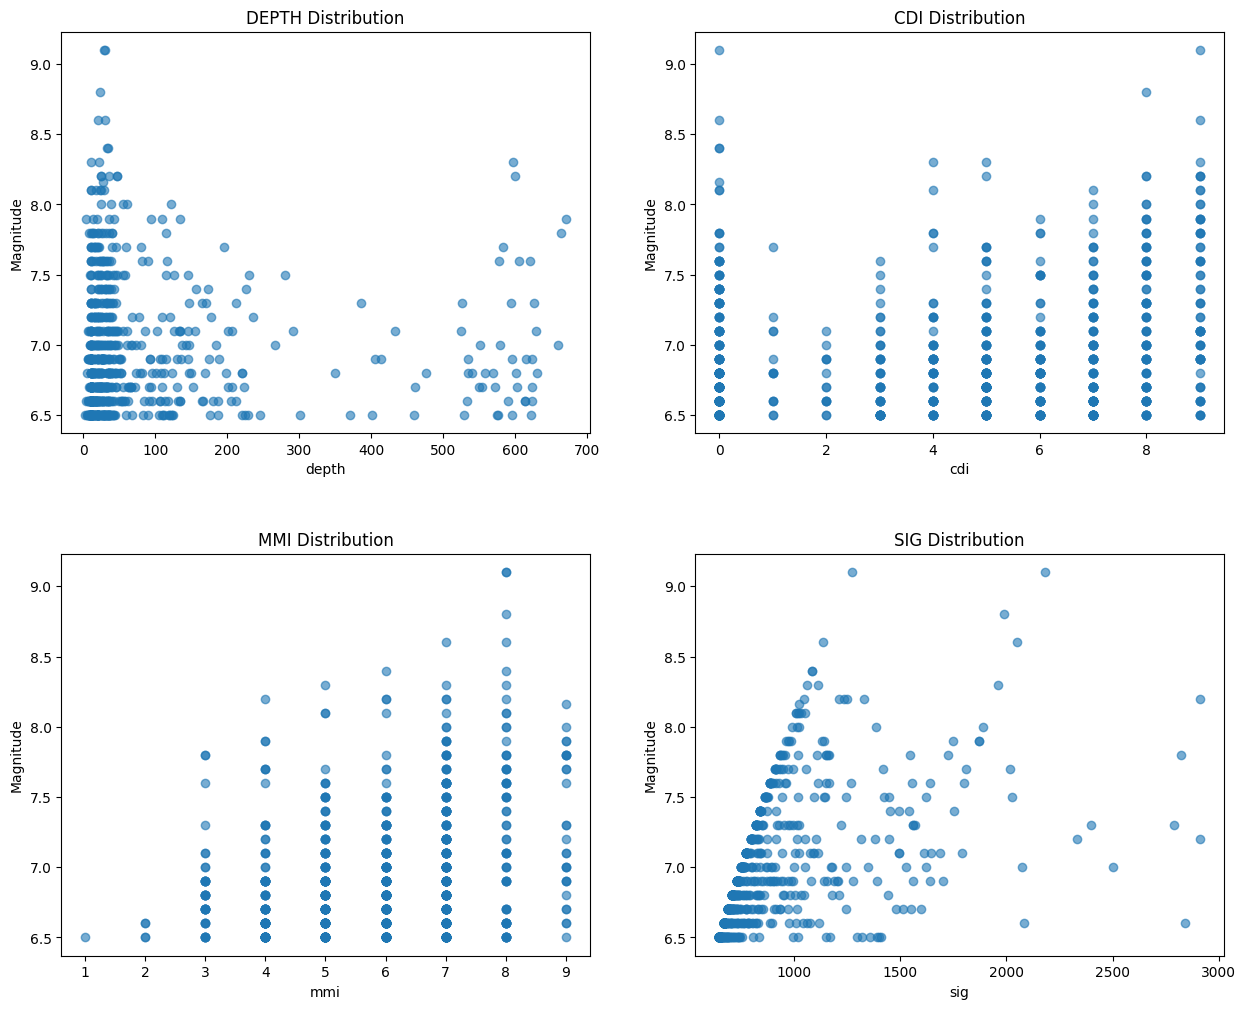

In [ ]:
#Distribution analysis for key features and magnitude relationship
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.subplots_adjust(hspace=0.3)
axes = axes.ravel()

for i, feature in enumerate(key_features[1:5]): 
    axes[i].scatter(earthquake_data[feature], earthquake_data['magnitude'], alpha=0.6)
    axes[i].set_title(f'{feature.upper()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Magnitude')


GEOGRAPHIC ANALYSIS


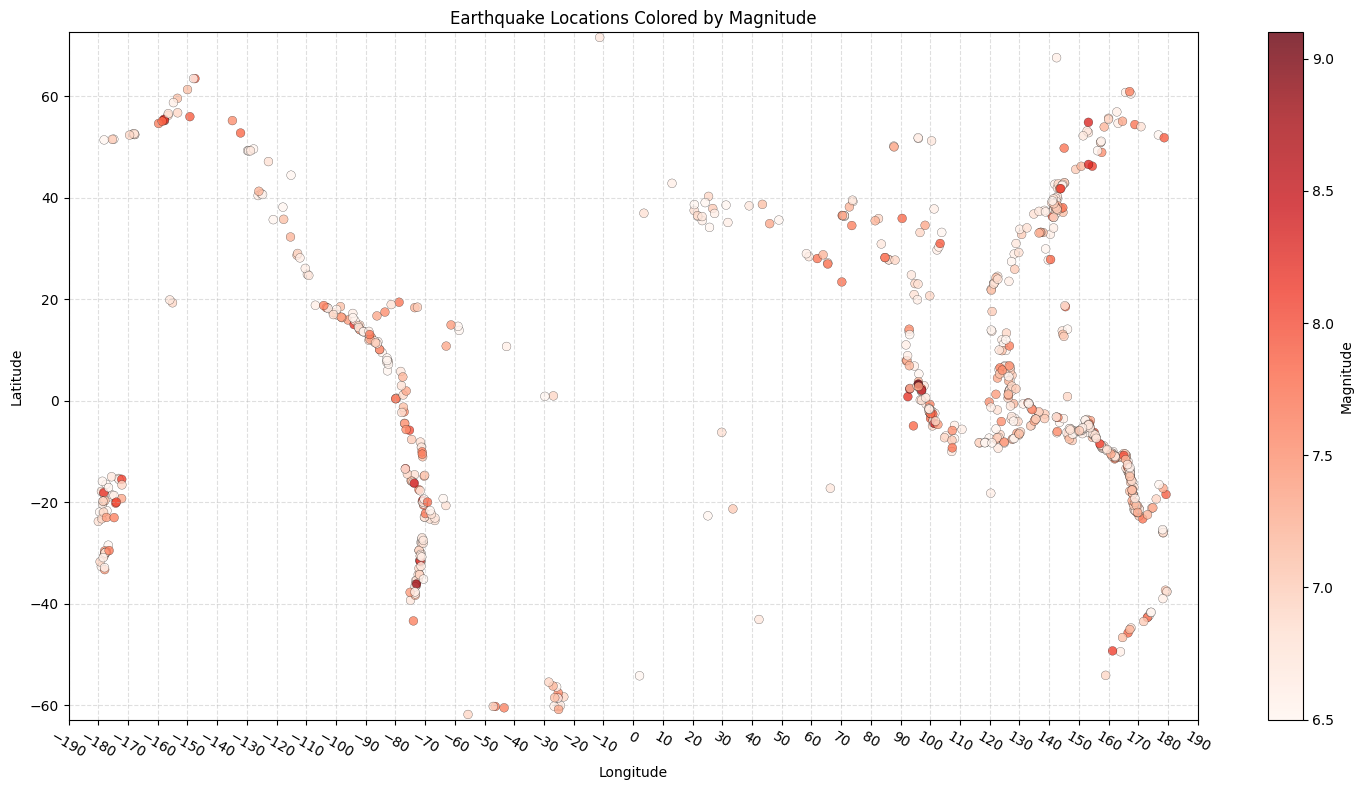

In [10]:
# 7. Geographic analysis
print("\nGEOGRAPHIC ANALYSIS")

plt.figure(figsize=(15, 8))
scatter = plt.scatter(
    earthquake_data['longitude'],
    earthquake_data['latitude'],
    c=earthquake_data['magnitude'],
    cmap='Reds',
    s=40,
    alpha=0.8,
    edgecolor='k',
    linewidth=0.2
)

cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

plt.title('Earthquake Locations Colored by Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)

lon_min = earthquake_data['longitude'].min()
lon_max = earthquake_data['longitude'].max()
lat_min = earthquake_data['latitude'].min()
lat_max = earthquake_data['latitude'].max()

plt.xlim(lon_min - 1, lon_max + 1)
plt.ylim(lat_min - 1, lat_max + 1)

xticks = np.arange(round(lon_min, -1) - 10, round(lon_max, -1) + 11, 10)
plt.xticks(xticks, rotation=-30)

plt.tight_layout()
plt.show()

![caption](./earth_long_lati.png)



TEMPORAL ANALYSIS


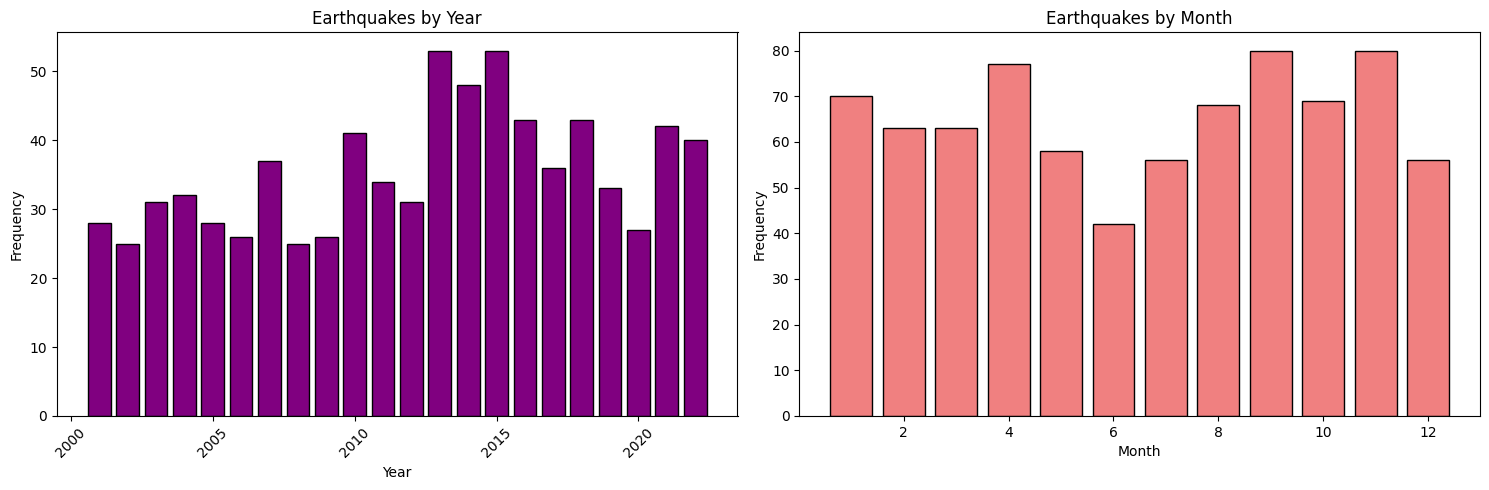

In [ ]:
# 8. Temporal analysis - means to analyze earthquake trends over time
print("\nTEMPORAL ANALYSIS")

yearly_counts = earthquake_data.groupby('Year').size()
monthly_counts = earthquake_data.groupby('Month').size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(yearly_counts.index, yearly_counts.values, color='purple', edgecolor='black')
ax1.set_title('Earthquakes by Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(monthly_counts.index, monthly_counts.values, color='lightcoral', edgecolor='black')
ax2.set_title('Earthquakes by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


TSUNAMI ANALYSIS

Tsunami occurrences:
tsunami
No Tsunami    478
Tsunami       304
Name: count, dtype: int64


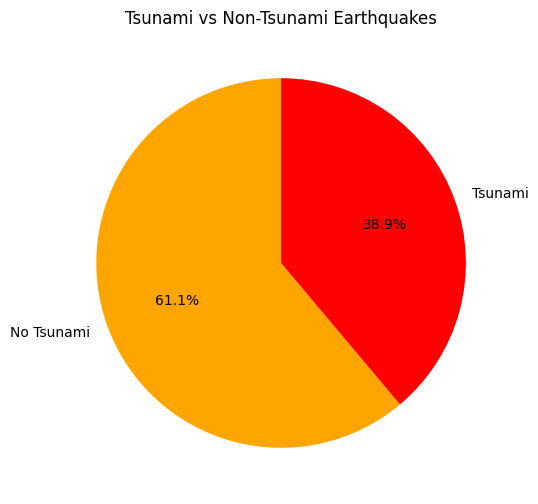

In [ ]:
# 9. Tsunami analysis
print("\nTSUNAMI ANALYSIS")
tsunami_counts = earthquake_data['tsunami'].value_counts()
tsunami_counts.index = tsunami_counts.index.map({0: 'No Tsunami', 1: 'Tsunami'})
print("\nTsunami occurrences:")
print(tsunami_counts)

plt.figure(figsize=(8, 6))
plt.pie(tsunami_counts, labels=tsunami_counts.index, autopct='%1.1f%%',
        colors=['orange', 'red'], startangle=90)
plt.title('Tsunami vs Non-Tsunami Earthquakes')
plt.show()

# Magnitude comparison for tsunami vs non-tsunami
fig = px.box(
        earthquake_data,
        x='tsunami',
        y='magnitude',
        title='Magnitude Distribution: Tsunami vs Non-Tsunami',
        labels={'tsunami': 'Tsunami (0=No, 1=Yes)', 'magnitude': 'Magnitude'},
        color='tsunami',
        color_discrete_map={0: 'orange', 1: 'red'}
)
fig.show()

# Phase 2: Data Preprocessing & Feature Engineering (ADVANCED)


In [ ]:
# Import additional libraries for preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Phase 2: Data Preprocessing & Feature Engineering (ADVANCED)
# Create a copy of the original data
processed_data = earthquake_data.copy()


# 1. Handle Missing Values
print("\n\n1. HANDLING MISSING VALUES")
print(f"\nMissing values before: {processed_data.isnull().sum().sum()}") #0 missing value

# outliers detected initially for key features
print("\nOutliers detected for key features before handling:")
key_features = ['depth', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap']
for feature in key_features:
    outliers, lower, upper = detect_outliers_iqr(processed_data, feature)
    print(f"{feature}: {len(outliers)} outliers detected")


# 2. Handle Outliers using IQR method
def cap_outliers_iqr(data, column, factor=1.5):
    """Cap outliers using IQR method instead of removing them"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    # Cap the outliers
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])

    return data

# Apply outlier capping to key numerical features (excluding target)
outlier_features = ['depth', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap']
for feature in outlier_features:
    if feature in processed_data.columns:
        processed_data = cap_outliers_iqr(processed_data, feature)

# outliers detected initially for key features
print("\nOutliers detected for key features after handling:")
key_features = ['depth', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap']
for feature in key_features:
    outliers, lower, upper = detect_outliers_iqr(processed_data, feature)
    print(f"{feature}: {len(outliers)} outliers detected")


# 3. Feature Engineering - Create derived features
print("\n\n3 FEATURE ENGINEERING")


processed_data['distance_from_pacific_center'] = np.sqrt(
    (processed_data['latitude'] - 0)**2 + (processed_data['longitude'] - 180)**2
)


processed_data['depth_latitude_interaction'] = processed_data['depth'] * abs(processed_data['latitude'])
processed_data['depth_longitude_interaction'] = processed_data['depth'] * abs(processed_data['longitude'])
processed_data['cdi_mmi_interaction'] = processed_data['cdi'] * processed_data['mmi']


processed_data['is_summer'] = processed_data['Month'].isin([6, 7, 8]).astype(int)
processed_data['is_winter'] = processed_data['Month'].isin([12, 1, 2]).astype(int)
processed_data['is_pacific_season'] = processed_data['Month'].isin([3, 4, 5, 6]).astype(int)  # Higher activity


processed_data['year_scaled'] = (processed_data['Year'] - processed_data['Year'].min()) / (processed_data['Year'].max() - processed_data['Year'].min())


processed_data['depth_log'] = np.log1p(processed_data['depth'])
processed_data['sig_log'] = np.log1p(processed_data['sig'])



new_features = ['distance_from_pacific_center', 'depth_latitude_interaction',
                'depth_longitude_interaction', 'cdi_mmi_interaction',
                'is_summer', 'is_winter', 'is_pacific_season', 'year_scaled',
                'depth_log', 'sig_log']


print(f"\nCreated {len(new_features)} new features:")
for feature in new_features:
    print(f"  -> {feature}")

# 4. Feature Selection
print("\n\n4. FEATURE SELECTION")


feature_cols = [col for col in processed_data.columns if col != 'magnitude']
X = processed_data[feature_cols]
y = processed_data['magnitude']

print(f"\nTotal features before selection: {X.shape[1]}")
print(f"Feature dtypes:\n{X.dtypes}")

# Method 1: Correlation-based selection
# Only use numeric columns for correlation
numeric_X = X.select_dtypes(include=[np.number])
print(f"\nNumeric features for correlation: {numeric_X.shape[1]}")
correlation_with_target = numeric_X.corrwith(y).abs().sort_values(ascending=False)
print("\nCorrelation with target (magnitude):")
print(correlation_with_target)
top_correlation_features = correlation_with_target.head(15).index.tolist()

# Method 2: Statistical feature selection (SelectKBest with f_regression)
# Only use numeric features for SelectKBest
numeric_X_full = X.select_dtypes(include=[np.number])
selector = SelectKBest(score_func=f_regression, k=15)
X_selected_temp = selector.fit_transform(numeric_X_full, y)
selected_mask = selector.get_support()
top_statistical_features = numeric_X_full.columns[selected_mask].tolist()

# Combine both methods and take unique features
top_features = list(set(top_correlation_features + top_statistical_features))
print(f"\nSelected {len(top_features)} top features using correlation + statistical methods")
print(pd.Series(top_features))


X_selected = X[top_features]
print(f"\nFinal feature set shape: {X_selected.shape}")

# 5. Feature Scaling
print("\n\n5. FEATURE SCALING")

# Use StandardScaler 
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=X_selected.columns,
    index=X_selected.index
)

print(f"\nFeatures scaled using StandardScaler")
print(f"Scaled data shape: {X_scaled.shape}")
# 6. Train-Test Split
print("\n\n6. TRAIN-TEST SPLIT")

# Split with stratification-like approach (since target is continuous, we'll use random split)
X_train, X_test, y_train, y_test = train_test_split( 
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train target mean: {y_train.mean():.1f}")
print(f"Test target mean: {y_test.mean():.1f}")

# 7. Final Data Quality Check
print("\n\n7. FINAL DATA QUALITY CHECK")
print(f"\nNo missing values: {X_train.isnull().sum().sum() + X_test.isnull().sum().sum() == 0}")
print(f"Features are scaled: {X_train.mean().abs().max() < 0.1}") 
print(f"Target distribution preserved: {abs(y_train.mean() - y_test.mean()) < 0.1}")  

# 8. Summary
print("\n\nPHASE 2 SUMMARY")
print(f"\nOriginal features: {len(earthquake_data.columns) - 1}")  
print(f"Engineered features: {len(new_features)}")
print(f"Selected features: {len(top_features)}")
print(f"Final training shape: {X_train.shape}")
print(f"Final test shape: {X_test.shape}")
print(f"Scaling method: StandardScaler")
print(f"Split ratio: 80-20")

# Display top features
print("\nTop 10 selected features by importance:")
feature_scores = pd.DataFrame({
    'Feature': top_features,
    'Correlation': [correlation_with_target.get(f, 0) for f in top_features]
})
feature_scores = feature_scores.sort_values('Correlation', ascending=False)
print(feature_scores.head(10).to_string(index=False))



1. HANDLING MISSING VALUES

Missing values before: 0

Outliers detected for key features before handling:
depth: 139 outliers detected
cdi: 0 outliers detected
mmi: 1 outliers detected
sig: 73 outliers detected
nst: 0 outliers detected
dmin: 61 outliers detected
gap: 48 outliers detected

Outliers detected for key features after handling:
depth: 0 outliers detected
cdi: 0 outliers detected
mmi: 0 outliers detected
sig: 0 outliers detected
nst: 0 outliers detected
dmin: 0 outliers detected
gap: 0 outliers detected


3 FEATURE ENGINEERING

Created 10 new features:
  -> distance_from_pacific_center
  -> depth_latitude_interaction
  -> depth_longitude_interaction
  -> cdi_mmi_interaction
  -> is_summer
  -> is_winter
  -> is_pacific_season
  -> year_scaled
  -> depth_log
  -> sig_log


4. FEATURE SELECTION

Total features before selection: 22
Feature dtypes:
cdi                             float64
mmi                             float64
sig                             float64
nst        


CORRELATION ANALYSIS


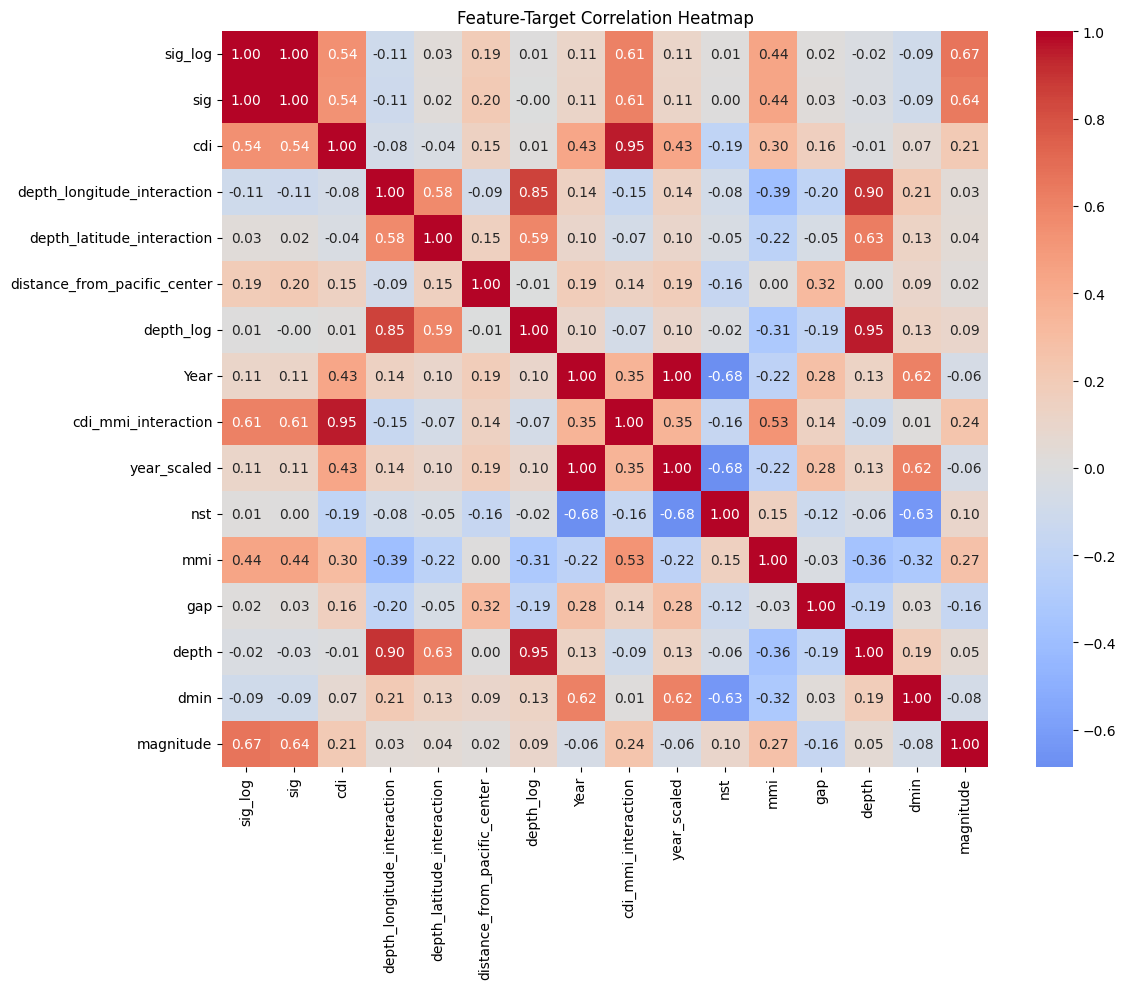

In [ ]:
print("\nCORRELATION ANALYSIS")

final_df_for_corr = pd.concat([X_train, y_train], axis=1)

numeric_cols = final_df_for_corr.select_dtypes(include=[np.number]).columns
final_correlation_matrix = final_df_for_corr[numeric_cols].corr()


magnitude_corr = final_correlation_matrix['magnitude'].sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(final_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature-Target Correlation Heatmap')
plt.tight_layout()
plt.show()

# Phase 3: Random Forest Model Development, Training & Testing


In [ ]:
# Phase 3: Random Forest Model Development, Training & Testing

# Import Random Forest and evaluation libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')

print("PHASE 3: RANDOM FOREST MODEL DEVELOPMENT")

# Step 1: Initialize and train baseline Random Forest model
print("\n\n1. BASELINE RANDOM FOREST MODEL")



rf_baseline = RandomForestRegressor(
    n_estimators=100,     
    random_state=42,       
    n_jobs=-1              
)


print("\nTraining baseline Random Forest model...")
rf_baseline.fit(X_train, y_train) #
print("\nBaseline model trained successfully!")


y_train_pred_baseline = rf_baseline.predict(X_train)
y_test_pred_baseline = rf_baseline.predict(X_test)


def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"  MAE (Mean Absolute Error): {mae:.4f}")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"  R² Score: {r2:.4f}")

    return mae, rmse, r2


print("\n\nBASELINE MODEL EVALUATION:")
train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred_baseline, "Training Set")
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred_baseline, "Test Set")


overfitting_check = train_r2 - test_r2
print(f"\nOverfitting Check (Train R² - Test R²): {overfitting_check:.4f}")
if overfitting_check > 0.1:
    print("Warning: Possible overfitting detected!")
else:
    print("No significant overfitting detected.")

# Step 2: Feature Importance Analysis
print("\n\n2. FEATURE IMPORTANCE ANALYSIS")


feature_importances = rf_baseline.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\n\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))


# Step 3: Hyperparameter Tuning with Grid Search
print("\n\n3. HYPERPARAMETER TUNING")



param_grid = {
    'n_estimators': [100, 200],        
    'max_depth': [10, 15, None],       
    'min_samples_split': [2, 5],       
    'min_samples_leaf': [1, 2],        
    'max_features': ['sqrt']           
}

print("\nPerforming Grid Search with Cross-Validation...")
print("\nThis may take a few minutes...")


rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,                   
    scoring='r2',           
    n_jobs=-1,              
    verbose=1               
)


rf_grid.fit(X_train, y_train)


best_params = rf_grid.best_params_
best_rf_model = rf_grid.best_estimator_  ### actual model with best parameters

print("\nGrid Search Complete!")
print(f"Best Parameters:\n{pd.DataFrame([best_params])}")
print(f"Best Cross-Validation Score: {rf_grid.best_score_:.4f}")

# Step 4: Train Optimized Model
print("\n\n4. OPTIMIZED MODEL TRAINING")



print("\nUsing best model from hyperparameter tuning...")

print(f"Features use for Final Model are:\n {pd.Series(X_train.columns)}")

y_train_pred_optimized = best_rf_model.predict(X_train)
y_test_pred_optimized = best_rf_model.predict(X_test)


print("\nOPTIMIZED MODEL EVALUATION:")
opt_train_mae, opt_train_rmse, opt_train_r2 = evaluate_model(y_train, y_train_pred_optimized, "Training Set")
opt_test_mae, opt_test_rmse, opt_test_r2 = evaluate_model(y_test, y_test_pred_optimized, "Test Set")

# Step 5: Cross-Validation Scores
print("\n\n5. CROSS-VALIDATION PERFORMANCE")



cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Step 6: Model Comparison and Performance Analysis
print("\n\n6. MODEL COMPARISON")


comparison_df = pd.DataFrame({
    'Model': ['Baseline RF', 'Optimized RF'],
    'Train_R2': [train_r2, opt_train_r2],
    'Test_R2': [test_r2, opt_test_r2],
    'Train_RMSE': [train_rmse, opt_train_rmse],
    'Test_RMSE': [test_rmse, opt_test_rmse],
    'Train_MAE': [train_mae, opt_train_mae],
    'Test_MAE': [test_mae, opt_test_mae]
})

print("\nPerformance Comparison:")
print(comparison_df.round(4).to_string(index=False))


r2_improvement = opt_test_r2 - test_r2
rmse_improvement = test_rmse - opt_test_rmse

print("\nPerformance Improvement:")
print(f"R² Improvement: {r2_improvement:.4f}")
print(f"RMSE Improvement: {rmse_improvement:.4f}")





# Step 8: Final Model Summary and Insights
print("\n\n8. FINAL MODEL SUMMARY & INSIGHTS")


print("\nRANDOM FOREST MODEL SUMMARY:")
print(f"• Best Parameters: {best_params}")
print(f"• Training R²: {opt_train_r2:.4f}")
print(f"• Test R²: {opt_test_r2:.4f}")
print(f"• Test RMSE: {opt_test_rmse:.4f}")
print(f"• Test MAE: {opt_test_mae:.4f}")
print(f"• Cross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n\nKEY INSIGHTS:")
print(f"• Top predictor: {importance_df.iloc[0]['Feature']} (importance: {importance_df.iloc[0]['Importance']:.4f})")
print(f"• Model improvement: {r2_improvement:.4f} R² increase after tuning")
print(f"• Cross-validation stability: CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


print("\nPREDICTION ACCURACY:")
print(f"• Average prediction error: ±{opt_test_rmse:.2f} magnitude units")
print(f"• Magnitude range in data: {y_test.min():.1f} - {y_test.max():.1f}")


PHASE 3: RANDOM FOREST MODEL DEVELOPMENT


1. BASELINE RANDOM FOREST MODEL

Training baseline Random Forest model...

Baseline model trained successfully!


BASELINE MODEL EVALUATION:

Training Set Performance:
  MAE (Mean Absolute Error): 0.0524
  RMSE (Root Mean Squared Error): 0.0961
  R² Score: 0.9563

Test Set Performance:
  MAE (Mean Absolute Error): 0.1097
  RMSE (Root Mean Squared Error): 0.1950
  R² Score: 0.7246

Overfitting Check (Train R² - Test R²): 0.2318


2. FEATURE IMPORTANCE ANALYSIS


Top 10 Most Important Features:
                     Feature  Importance
                         sig    0.333071
                     sig_log    0.246956
distance_from_pacific_center    0.072036
 depth_longitude_interaction    0.065855
                         gap    0.055158
                         cdi    0.046484
         cdi_mmi_interaction    0.042884
  depth_latitude_interaction    0.041105
                         nst    0.019578
                        dmin    0.014637


3. HYP



7. PREDICTION ANALYSIS & VISUALIZATION


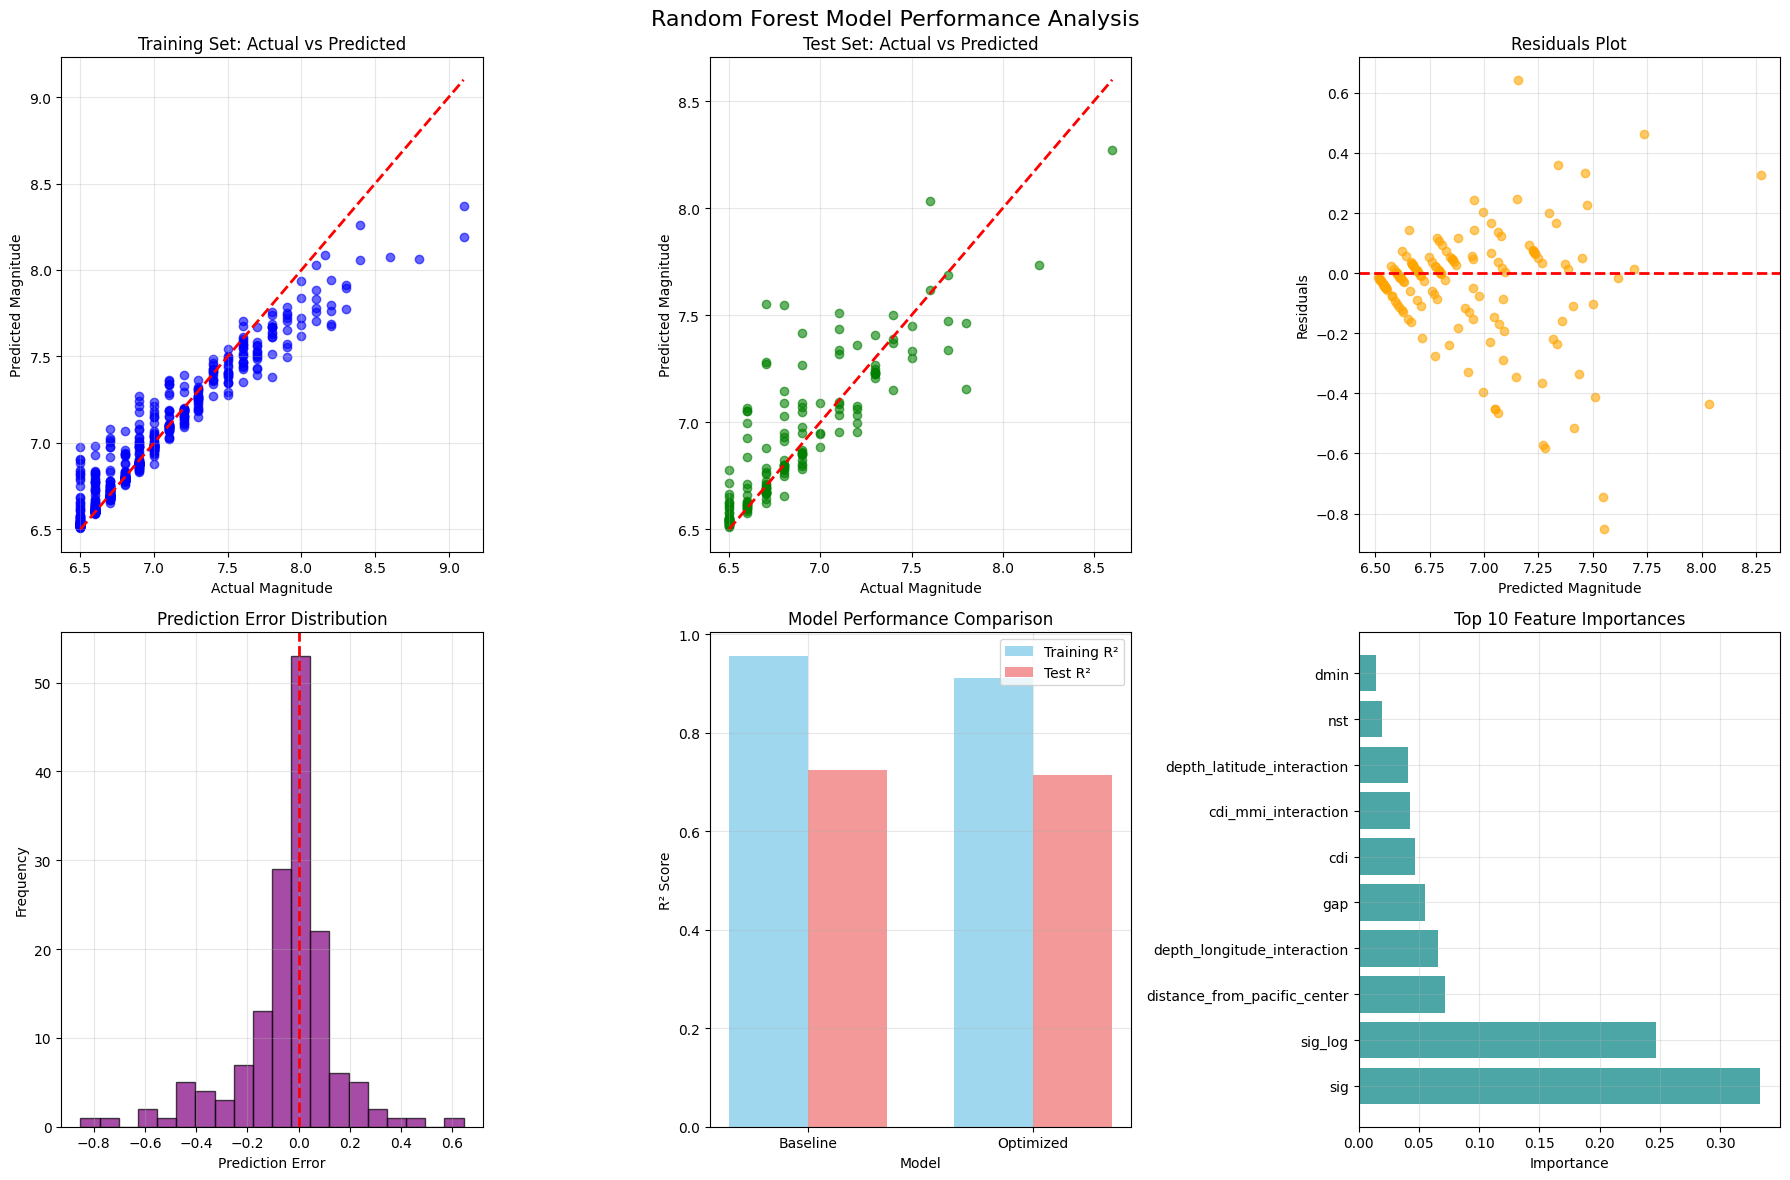

In [ ]:
# Step 7: Visual Analysis of Predictions
print("\n\n7. PREDICTION ANALYSIS & VISUALIZATION")



fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Random Forest Model Performance Analysis', fontsize=16)

# 1. Actual vs Predicted (Training)
axes[0,0].scatter(y_train, y_train_pred_optimized, alpha=0.6, color='blue')
axes[0,0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Magnitude')
axes[0,0].set_ylabel('Predicted Magnitude')
axes[0,0].set_title('Training Set: Actual vs Predicted')
axes[0,0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (Test)
axes[0,1].scatter(y_test, y_test_pred_optimized, alpha=0.6, color='green')
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_xlabel('Actual Magnitude')
axes[0,1].set_ylabel('Predicted Magnitude')
axes[0,1].set_title('Test Set: Actual vs Predicted')
axes[0,1].grid(True, alpha=0.3)

# 3. Residuals Plot
residuals = y_test - y_test_pred_optimized
axes[0,2].scatter(y_test_pred_optimized, residuals, alpha=0.6, color='orange')
axes[0,2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0,2].set_xlabel('Predicted Magnitude')
axes[0,2].set_ylabel('Residuals')
axes[0,2].set_title('Residuals Plot')
axes[0,2].grid(True, alpha=0.3)

# 4. Prediction Error Distribution
axes[1,0].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1,0].set_xlabel('Prediction Error')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Prediction Error Distribution')
axes[1,0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1,0].grid(True, alpha=0.3)

# 5. Model Improvement Comparison
models = ['Baseline', 'Optimized']
train_scores = [train_r2, opt_train_r2]
test_scores = [test_r2, opt_test_r2]

x = np.arange(len(models))
width = 0.35

axes[1,1].bar(x - width/2, train_scores, width, label='Training R²', alpha=0.8, color='skyblue')
axes[1,1].bar(x + width/2, test_scores, width, label='Test R²', alpha=0.8, color='lightcoral')
axes[1,1].set_xlabel('Model')
axes[1,1].set_ylabel('R² Score')
axes[1,1].set_title('Model Performance Comparison')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Feature Importance (Top 10)
top_10_features = importance_df.head(10)
axes[1,2].barh(top_10_features['Feature'], top_10_features['Importance'], color='teal', alpha=0.7)
axes[1,2].set_xlabel('Importance')
axes[1,2].set_title('Top 10 Feature Importances')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Phase 4: Earthquake Alert System Based on Predicted Magnitude

print("PHASE 4: EARTHQUAKE ALERT SYSTEM")

def earthquake_alert_system(predicted_magnitude, latitude=None, longitude=None):
    """
    Generate earthquake alert based on predicted magnitude with severity levels and descriptions.

    Parameters:
    predicted_magnitude (float): The predicted earthquake magnitude
    latitude (float, optional): Latitude of the earthquake location
    longitude (float, optional): Longitude of the earthquake location

    Returns:
    dict: Alert information including level, description, and recommended actions
    """

    if predicted_magnitude < 5.5:
        alert_level = "MINOR-GREEN ALERT"
        severity_color = "🟢 GREEN"
        description = "Generally not felt by people, though recorded on local instruments."
        damage_potential = "Little to no damage expected."
        recommended_actions = [
            "No immediate action required",
            "Monitor local news for updates",
            "Check for aftershocks if felt locally"
        ]

    elif 5.5 <= predicted_magnitude < 6.0:
        alert_level = "MODERATE-YELLOW ALERT"
        severity_color = "🟡 YELLOW"
        description = "Felt by most people; may cause damage to weak structures."
        damage_potential = "Some damage to weak structures and slight damage to well-constructed buildings."
        recommended_actions = [
            "Secure loose objects indoors",
            "Check for structural damage in older buildings",
            "Prepare emergency kit",
            "Stay informed through official channels"
        ]

    elif 6.0 <= predicted_magnitude < 7.0:
        alert_level = "STRONG-ORANGE ALERT"
        severity_color = "🟠 ORANGE"
        description = "Strong shaking and rolling; may cause damage even to well-built structures."
        damage_potential = "Damage to buildings in populous areas, especially poor construction, over roughly 100 km."
        recommended_actions = [
            "Evacuate unsafe buildings immediately",
            "Move to open areas away from buildings and power lines",
            "Prepare for potential aftershocks",
            "Follow local emergency procedures",
            "Contact emergency services if injured"
        ]

    elif 7.0 <= predicted_magnitude < 8.0:
        alert_level = "SEVERE-RED AlERT"
        severity_color = "🔴 RED"
        description = "Major earthquake; great destruction and loss of life possible."
        damage_potential = "Serious damage over large areas; bridges, railways, highways, airports and other structures damaged."
        recommended_actions = [
            "IMMEDIATE EVACUATION REQUIRED",
            "Move to designated safe zones",
            "Avoid using elevators",
            "Stay away from windows and heavy objects",
            "Follow emergency broadcast instructions",
            "Prepare for long-term disruption"
        ]

    else:  
        alert_level = "DEVASTATING-PURPLE ALERT"
        severity_color = "🟣 PURPLE"
        description = "Great earthquake; total destruction and very high casualties."
        damage_potential = "Total destruction and high casualties near the epicenter; major damage in areas hundreds of km away."
        recommended_actions = [
            "CRITICAL EMERGENCY - IMMEDIATE ACTION REQUIRED",
            "Evacuate to highest ground if near coast (tsunami risk)",
            "Seek shelter in reinforced buildings if possible",
            "Expect widespread infrastructure failure",
            "Follow national emergency protocols",
            "Prepare for humanitarian crisis response"
        ]

    # Compute an approximate affected area range from the predicted magnitude
    if predicted_magnitude < 5.5:
        range_area = "Very localized area"
    elif predicted_magnitude < 6.0:
        range_area = "Neighborhood-scale area"
    elif predicted_magnitude < 7.0:
        range_area = "City-scale area"
    elif predicted_magnitude < 8.0:
        range_area = "Regional area"
    else:
        range_area = "Very large regional area"

    if latitude is not None and longitude is not None:
        location = f"Latitude {latitude:.4f}, Longitude {longitude:.4f}"
    else:
        location = "Unknown location"

    alert_info = {
        "magnitude": predicted_magnitude,
        "alert_level": alert_level,
        "severity_color": severity_color,
        "description": description,
        "damage_potential": damage_potential,
        "recommended_actions": recommended_actions,
        "location": location,
        "range_area": range_area,
        "timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    return alert_info

def display_alert(alert_info):
    """
    Display formatted earthquake alert information.
    """
    print(f"\n{'_'*80}")
    print(f"🚨 EARTHQUAKE ALERT SYSTEM - PREDICTED MAGNITUDE: {alert_info['magnitude']:.2f}")
    print(f"{'_'*80}")
    print(f"Alert Level: {alert_info['alert_level']} {alert_info['severity_color']}")
    print(f"Timestamp: {alert_info['timestamp']}")
    print(f"Location: {alert_info['location']}")
    print(f"Affected Range Area: {alert_info['range_area']}")
    print(f"\n📝 Description: {alert_info['description']}")
    print(f"🏗️  Damage Potential: {alert_info['damage_potential']}")

    print(f"\n⚡ Recommended Actions:")

    for i, action in enumerate(alert_info['recommended_actions'], 1):
        print(f"   {i}. {action}")

PHASE 4: EARTHQUAKE ALERT SYSTEM


In [ ]:
# Step 1: Test the alert system with sample predictions
print("\nTESTING ALERT SYSTEM WITH SAMPLE PREDICTIONS")


test_magnitudes = [5.2, 5.7, 6.3, 7.2, 8.5]

print("Sample Alert Tests:")
for mag in test_magnitudes:
    alert = earthquake_alert_system(mag)
    display_alert(alert)




TESTING ALERT SYSTEM WITH SAMPLE PREDICTIONS
Sample Alert Tests:

________________________________________________________________________________
🚨 EARTHQUAKE ALERT SYSTEM - PREDICTED MAGNITUDE: 5.20
________________________________________________________________________________
Alert Level: MINOR-GREEN ALERT 🟢 GREEN
Timestamp: 2026-04-09 22:27:40
Location: Unknown location
Affected Range Area: Very localized area

📝 Description: Generally not felt by people, though recorded on local instruments.
🏗️  Damage Potential: Little to no damage expected.

⚡ Recommended Actions:
   1. No immediate action required
   2. Monitor local news for updates
   3. Check for aftershocks if felt locally

________________________________________________________________________________
🚨 EARTHQUAKE ALERT SYSTEM - PREDICTED MAGNITUDE: 5.70
________________________________________________________________________________
Alert Level: MODERATE-YELLOW ALERT 🟡 YELLOW
Timestamp: 2026-04-09 22:27:40
Location: U

In [ ]:
# Step 2: Apply alert system to our Random Forest predictions
print("\n2. APPLYING ALERT SYSTEM TO RANDOM FOREST PREDICTIONS")


test_predictions = best_rf_model.predict(X_test)


results_df = pd.DataFrame({
    'Actual_Magnitude': y_test,
    'Predicted_Magnitude': test_predictions,
    'Prediction_Error': y_test - test_predictions
})


results_df['Predicted_Alert_Level'] = results_df['Predicted_Magnitude'].apply(
    lambda x: earthquake_alert_system(x)['alert_level']
)


results_df['Actual_Alert_Level'] = results_df['Actual_Magnitude'].apply(
    lambda x: earthquake_alert_system(x)['alert_level']
)

print(f"\nAlert Distribution in Test Set ({len(results_df)} predictions):")
alert_counts = results_df['Predicted_Alert_Level'].value_counts()
print(alert_counts)

# Step 3: Alert accuracy analysis
print("\n3. ALERT ACCURACY ANALYSIS")

correct_alerts = (results_df['Predicted_Alert_Level'] == results_df['Actual_Alert_Level']).sum()
total_predictions = len(results_df)
alert_accuracy = correct_alerts / total_predictions * 100

print(f"Alert Level Prediction Accuracy: {alert_accuracy:.1f}%")
print(f"Correct Alert Predictions: {correct_alerts}/{total_predictions}")



2. APPLYING ALERT SYSTEM TO RANDOM FOREST PREDICTIONS

Alert Distribution in Test Set (157 predictions):
Predicted_Alert_Level
STRONG-ORANGE ALERT         104
SEVERE-RED AlERT             51
DEVASTATING-PURPLE ALERT      2
Name: count, dtype: int64

3. ALERT ACCURACY ANALYSIS
Alert Level Prediction Accuracy: 85.4%
Correct Alert Predictions: 134/157


In [ ]:
# Phase 5: User Input Prediction System with Alert

print("PHASE 5: EARTHQUAKE MAGNITUDE PREDICTION & ALERT SYSTEM")


def predict_earthquake_magnitude(test_mode=False):
    """
    Interactive system for predicting earthquake magnitude and issuing alerts.
    Takes user input, transforms features, makes prediction, and generates alert.
    
    Parameters:
    test_mode (bool): If True, uses fixed test values instead of user input.
    """

    print("\nEARTHQUAKE MAGNITUDE PREDICTION SYSTEM")
    print("Enter the following earthquake parameters:")
    print("-" * 50)

    # Get user input 
    try:
        if test_mode:
            
            cdi = 8.0
            mmi = 7.0
            sig = 768.0
            nst = 117.0
            dmin = 0.509
            gap = 17.0
            depth = 14.0
            latitude = -9.7963
            longitude = 159.596
            year = 2022
            month = 11
            tsunami = 1
            
            print("TEST MODE: Using sample values from dataset")
            print(f"CDI: {cdi}, MMI: {mmi}, SIG: {sig}, NST: {nst}, DMIN: {dmin}")
            print(f"GAP: {gap}, DEPTH: {depth}, LAT: {latitude}, LON: {longitude}")
            print(f"YEAR: {year}, MONTH: {month}, TSUNAMI: {tsunami}")
        else:
            
            cdi = float(input("CDI (Community Determined Intensity, 0-10): "))
            mmi = float(input("MMI (Modified Mercalli Intensity, 0-10): "))
            sig = float(input("SIG (Significance, 0-1000+): "))
            nst = float(input("NST (Number of Stations, 0-100+): "))
            dmin = float(input("DMIN (Minimum Distance to Station, km): "))
            gap = float(input("GAP (Azimuthal Gap, degrees, 0-360): "))
            depth = float(input("DEPTH (Earthquake Depth, km): "))
            latitude = float(input("LATITUDE (decimal degrees, -90 to 90): "))
            longitude = float(input("LONGITUDE (decimal degrees, -180 to 180): "))
            year = int(input("YEAR (e.g., 2023): "))
            month = int(input("MONTH (1-12): "))
            tsunami = int(input("TSUNAMI (0=No, 1=Yes): "))

        print("INPUT RECEIVED - PROCESSING...")

        # Step 1: Feature Engineering (same as training)

        
        distance_from_pacific_center = float(np.sqrt((latitude - 0)**2 + (longitude - 180)**2))
        depth_latitude_interaction = depth * abs(latitude)
        depth_longitude_interaction = depth * abs(longitude)
        cdi_mmi_interaction = cdi * mmi

        
        # From training data (2021-2022)
        year_min = 2021  
        year_max = 2022  
        year_scaled = (year - year_min) / (year_max - year_min)

        
        depth_log = float(np.log1p(depth))
        sig_log = float(np.log1p(sig))

        # Step 2: Create feature array in correct order

        
        model_features = [
            'sig_log', 'sig', 'cdi', 'depth_longitude_interaction', 'depth_latitude_interaction', 
            'distance_from_pacific_center', 'depth_log', 'Year', 'cdi_mmi_interaction', 
            'year_scaled', 'nst', 'mmi', 'gap', 'depth', 'dmin'
        ]

        feature_values = [
            sig_log,                    # sig_log
            sig,                        # sig
            cdi,                        # cdi
            depth_longitude_interaction, # depth_longitude_interaction
            depth_latitude_interaction,  # depth_latitude_interaction
            distance_from_pacific_center, # distance_from_pacific_center
            depth_log,                  # depth_log
            float(year),                # Year
            cdi_mmi_interaction,        # cdi_mmi_interaction
            year_scaled,                # year_scaled
            nst,                        # nst
            mmi,                        # mmi
            gap,                        # gap
            depth,                      # depth
            dmin                        # dmin
        ]

        
        input_df = pd.DataFrame([feature_values], columns=model_features)

        # Step 3: Scale features (using same scaler as training)
        input_scaled = scaler.transform(input_df)

        # Step 4: Make prediction
        predicted_magnitude = best_rf_model.predict(input_scaled)[0]

        # Step 5: Generate and display alert
        alert = earthquake_alert_system(predicted_magnitude, latitude=latitude, longitude=longitude)
        display_alert(alert)

    except Exception as e:
        error_msg = str(e)
        if "feature names" in error_msg.lower():
            print(f"ERROR: Feature mismatch with training data!")
            print(f"Error details: {e}")
            print("This means the input features don't match the model's expected features.")
        else:
            print(f"ERROR: Invalid input! Please enter numeric values only.")
            print(f"Error details: {e}")
        return None, None

PHASE 5: EARTHQUAKE MAGNITUDE PREDICTION & ALERT SYSTEM


In [ ]:
predict_earthquake_magnitude()


EARTHQUAKE MAGNITUDE PREDICTION SYSTEM
Enter the following earthquake parameters:
--------------------------------------------------
INPUT RECEIVED - PROCESSING...

________________________________________________________________________________
🚨 EARTHQUAKE ALERT SYSTEM - PREDICTED MAGNITUDE: 6.93
________________________________________________________________________________
Alert Level: STRONG-ORANGE ALERT 🟠 ORANGE
Timestamp: 2026-04-09 22:29:43
Location: Latitude -9.7000, Longitude 159.5900
Affected Range Area: City-scale area

📝 Description: Strong shaking and rolling; may cause damage even to well-built structures.
🏗️  Damage Potential: Damage to buildings in populous areas, especially poor construction, over roughly 100 km.

⚡ Recommended Actions:
   1. Evacuate unsafe buildings immediately
   2. Move to open areas away from buildings and power lines
   3. Prepare for potential aftershocks
   4. Follow local emergency procedures
   5. Contact emergency services if injured
